In [1]:
import random
import torch

import clip
import utils
import data_utils
import similarity

import matplotlib
from matplotlib import pyplot as plt

/home/s4yadav/private/workspace/CLIP-dissect/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


## Settings

In [2]:
clip_name = 'ViT-B/16'
target_name = 'resnet50'
target_layer = 'layer4'
d_probe = 'imagenet_broden'
concept_set = 'data/3k.txt'
batch_size = 16
device = 'cuda'
pool_mode = 'avg'

save_dir = 'saved_activations'
similarity_fn = similarity.soft_wpmi

## Quantization

In [4]:
import quantization_utils_awq

# Quantization settings
quantize_enabled = True  # Set to False to disable quantization
quantization_bits = 8    # INT8 quantization
quantization_group_size = 0  # 0 = per-channel, otherwise group-wise

if quantize_enabled:
    target_model_to_use = quantization_utils_awq.quantize_given_mdodel(
        target_name,
        quantization_bits,
        quantization_group_size,
        device
    )
else:
    print(f"Quantization disabled. Using original {target_name} model.")
    target_model_to_use = None  # Will load default in save_activations

Loading resnet50 model for quantization...


Quantizing resnet50 with 8-bit AWQ quantization...
Model quantized successfully!
Model size statistics:
  INT8 parameters: 24.32 MB
  FP32 equivalent: 0.20 MB
  Compression ratio: 0.01x


In [5]:
def save_activations_with_quantization(clip_name, target_name, target_model_to_use, target_layers, d_probe, concept_set, pool_mode, save_dir, batch_size, device):
    # Load models
    clip_model, clip_preprocess = clip.load(clip_name, device=device)

    if quantize_enabled and target_model_to_use is not None:
        # Use quantized model
        target_model = target_model_to_use
        target_preprocess = data_utils.get_target_model(target_name, device)[1]  # Get preprocessor only
    else:
        # Load default model
        target_model, target_preprocess = data_utils.get_target_model(target_name, device)

    # Setup data
    data_c = data_utils.get_data(d_probe, clip_preprocess)
    data_t = data_utils.get_data(d_probe, target_preprocess)

    with open(concept_set, 'r') as f: 
        words = (f.read()).split('\n')

    # Ignore empty lines
    words = [i for i in words if i != ""]

    # Generate text embeddings
    text = clip.tokenize(["{}".format(word) for word in words]).to(device)

    # Get save names
    save_names = utils.get_save_names(
        clip_name=clip_name,
        target_name=target_name,
        target_layer='{}',
        d_probe=d_probe,
        concept_set=concept_set,
        pool_mode=pool_mode,
        save_dir=save_dir
    )

    target_save_name, clip_save_name, text_save_name = save_names

    # Save features using quantized model (if enabled)
    print("Saving CLIP text features...")
    utils.save_clip_text_features(clip_model, text, text_save_name, batch_size)

    print("Saving CLIP image features...")
    utils.save_clip_image_features(clip_model, data_c, clip_save_name, batch_size, device)

    print(f"Saving target activations from {'quantized ' if quantize_enabled else ''}model...")
    utils.save_target_activations(
        target_model,
        data_t,
        target_save_name,
        target_layers,
        batch_size,
        device,
        pool_mode
    )

    print("Activation extraction complete!")


## Run CLIP-Dissect

In [ ]:
save_activations_with_quantization(clip_name = clip_name, 
                       target_name = target_name, 
                       target_model_to_use=target_model_to_use, 
                       target_layers = [target_layer], 
                       d_probe = d_probe, 
                       concept_set = concept_set, 
                       batch_size = batch_size, 
                       device = device, 
                       pool_mode=pool_mode, 
                       save_dir = save_dir
                    )

Saving CLIP text features...
Saving CLIP image features...
Saving target activations from quantized model...
Activation extraction complete!


In [ ]:
save_names = utils.get_save_names(clip_name = clip_name, target_name = target_name,
                                  target_layer = target_layer, d_probe = d_probe,
                                  concept_set = concept_set, pool_mode=pool_mode,
                                  save_dir = save_dir)

target_save_name, clip_save_name, text_save_name = save_names

similarities, target_feats = utils.get_similarity_from_activations(target_save_name, clip_save_name, 
                                                             text_save_name, similarity_fn)

with open(concept_set, 'r') as f: 
    words = (f.read()).split('\n')

pil_data = data_utils.get_data(d_probe)

/home/s4yadav/private/workspace/CLIP-dissect/utils.py:153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  image_features = torch.load(clip_save_name, map_location='cpu').floa

torch.Size([2048, 3000])


## Visualize Results


 Layer:layer4 Neuron:1730
1st description: television, sim:2.151
2nd description: TV, sim:2.040
3rd description: monitor, sim:1.864
5 most highly activating images in D_probe:


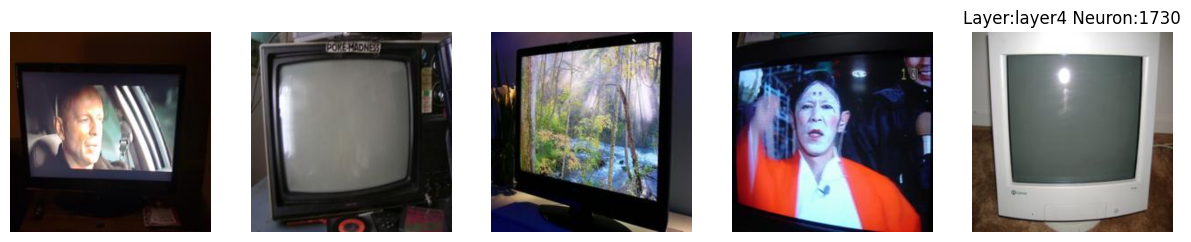


 Layer:layer4 Neuron:677
1st description: fabric, sim:1.492
2nd description: surface, sim:1.131
3rd description: gray, sim:1.060
5 most highly activating images in D_probe:


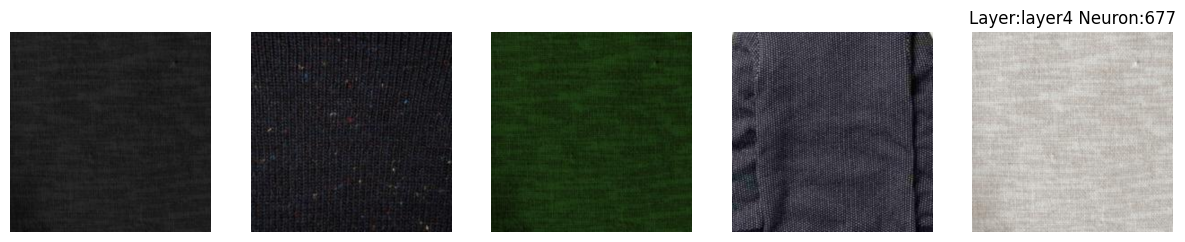


 Layer:layer4 Neuron:218
1st description: stair, sim:1.206
2nd description: telescope, sim:0.893
3rd description: tent, sim:0.888
5 most highly activating images in D_probe:


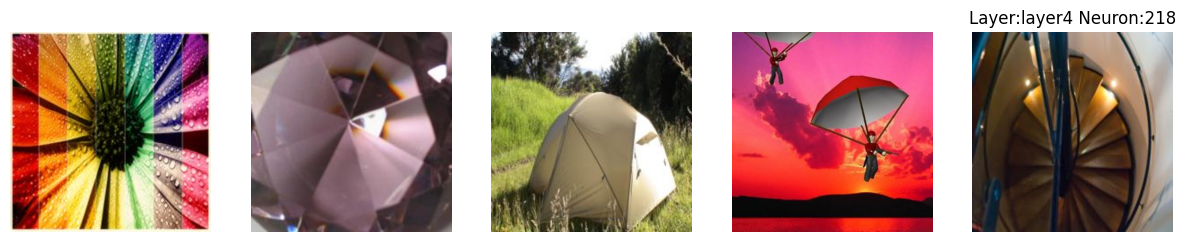


 Layer:layer4 Neuron:525
1st description: fabric, sim:1.573
2nd description: blanket, sim:1.539
3rd description: cotton, sim:1.394
5 most highly activating images in D_probe:


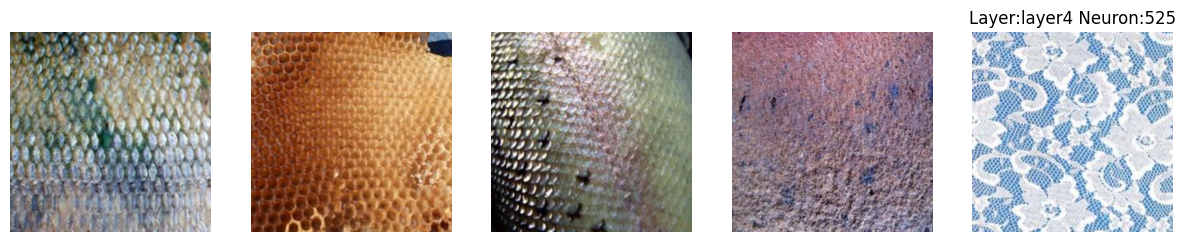


 Layer:layer4 Neuron:388
1st description: lawn, sim:1.071
2nd description: grass, sim:1.003
3rd description: golf, sim:0.783
5 most highly activating images in D_probe:


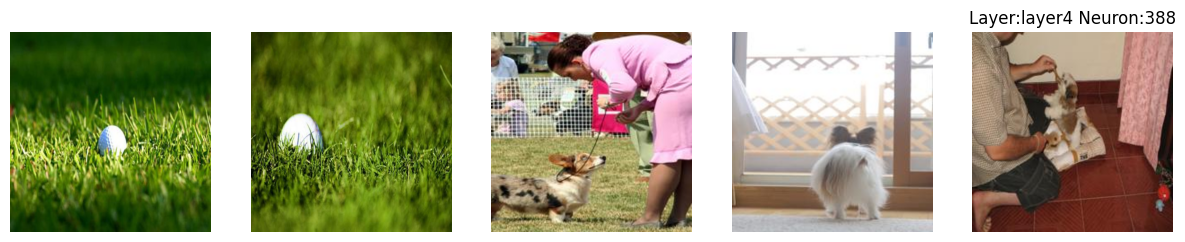


 Layer:layer4 Neuron:1099
1st description: truck, sim:2.676
2nd description: waste, sim:2.232
3rd description: refuse, sim:1.742
5 most highly activating images in D_probe:


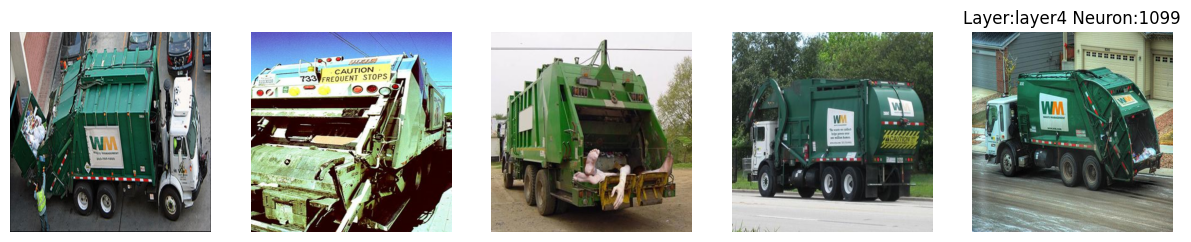


 Layer:layer4 Neuron:819
1st description: cotton, sim:0.865
2nd description: bread, sim:0.626
3rd description: head, sim:0.619
5 most highly activating images in D_probe:


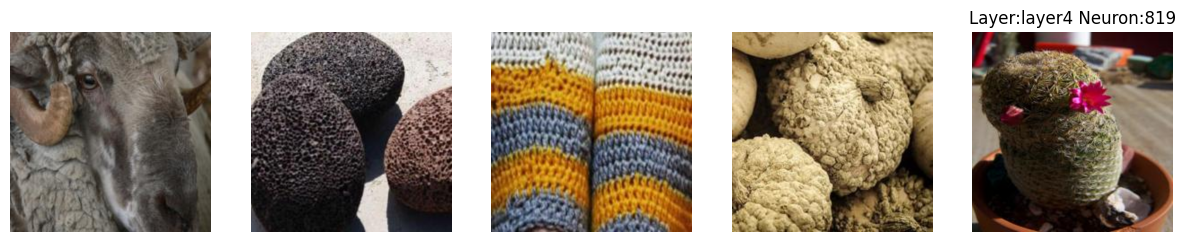


 Layer:layer4 Neuron:30
1st description: fabric, sim:1.166
2nd description: cotton, sim:0.862
3rd description: pattern, sim:0.815
5 most highly activating images in D_probe:


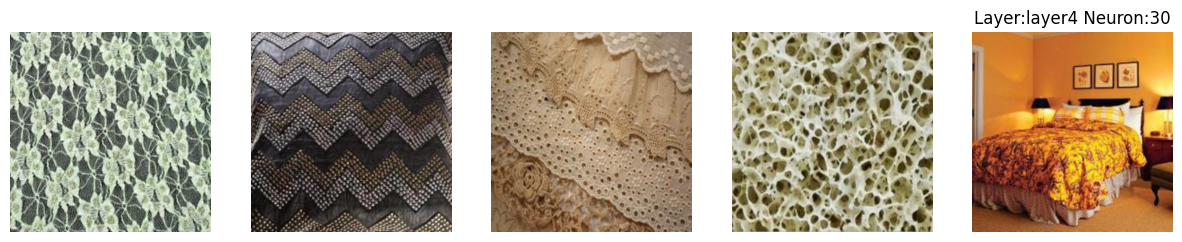


 Layer:layer4 Neuron:1785
1st description: dog, sim:0.924
2nd description: cow, sim:0.690
3rd description: pepper, sim:0.689
5 most highly activating images in D_probe:


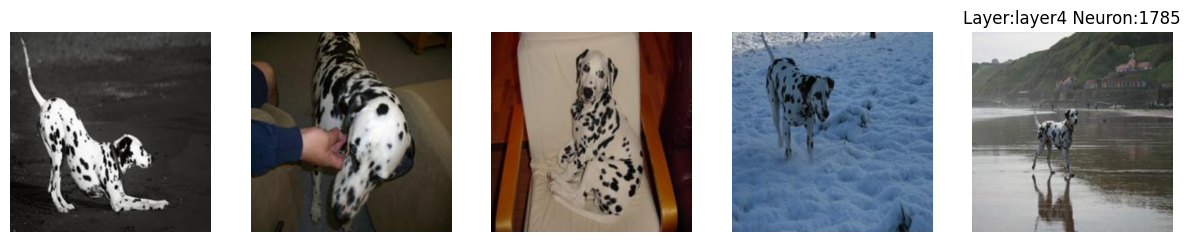


 Layer:layer4 Neuron:648
1st description: dog, sim:1.469
2nd description: adopt, sim:1.113
3rd description: pepper, sim:0.997
5 most highly activating images in D_probe:


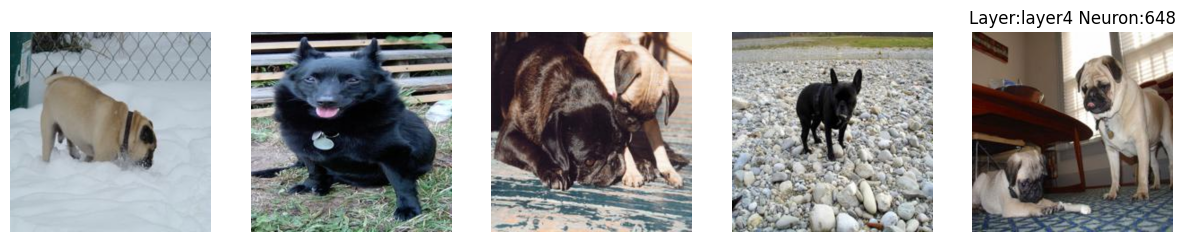

In [ ]:
neurons_to_check = ids_to_check = random.sample([i for i in range(target_feats.shape[1])], k=10)
#neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]

ranks = ["1st", "2nd", "3rd"]
top_vals, top_ids = torch.topk(target_feats, k=5, dim=0)

for orig_id in ids_to_check:

    print('\n Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    vals, ids = torch.topk(similarities[orig_id], k=3, largest=True)
    for i in range(len(vals)):
        print("{} description: {}, sim:{:.3f}".format(ranks[i], words[int(ids[i])], vals[i]))
    
    print("5 most highly activating images in D_probe:")
    fig = plt.figure(figsize=(15, 7))
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        fig.add_subplot(1, 5, i+1)
        plt.imshow(im)
        plt.axis('off')
        
    plt.title('Layer:{} Neuron:{}'.format(target_layer, (int(orig_id))))
    plt.show()

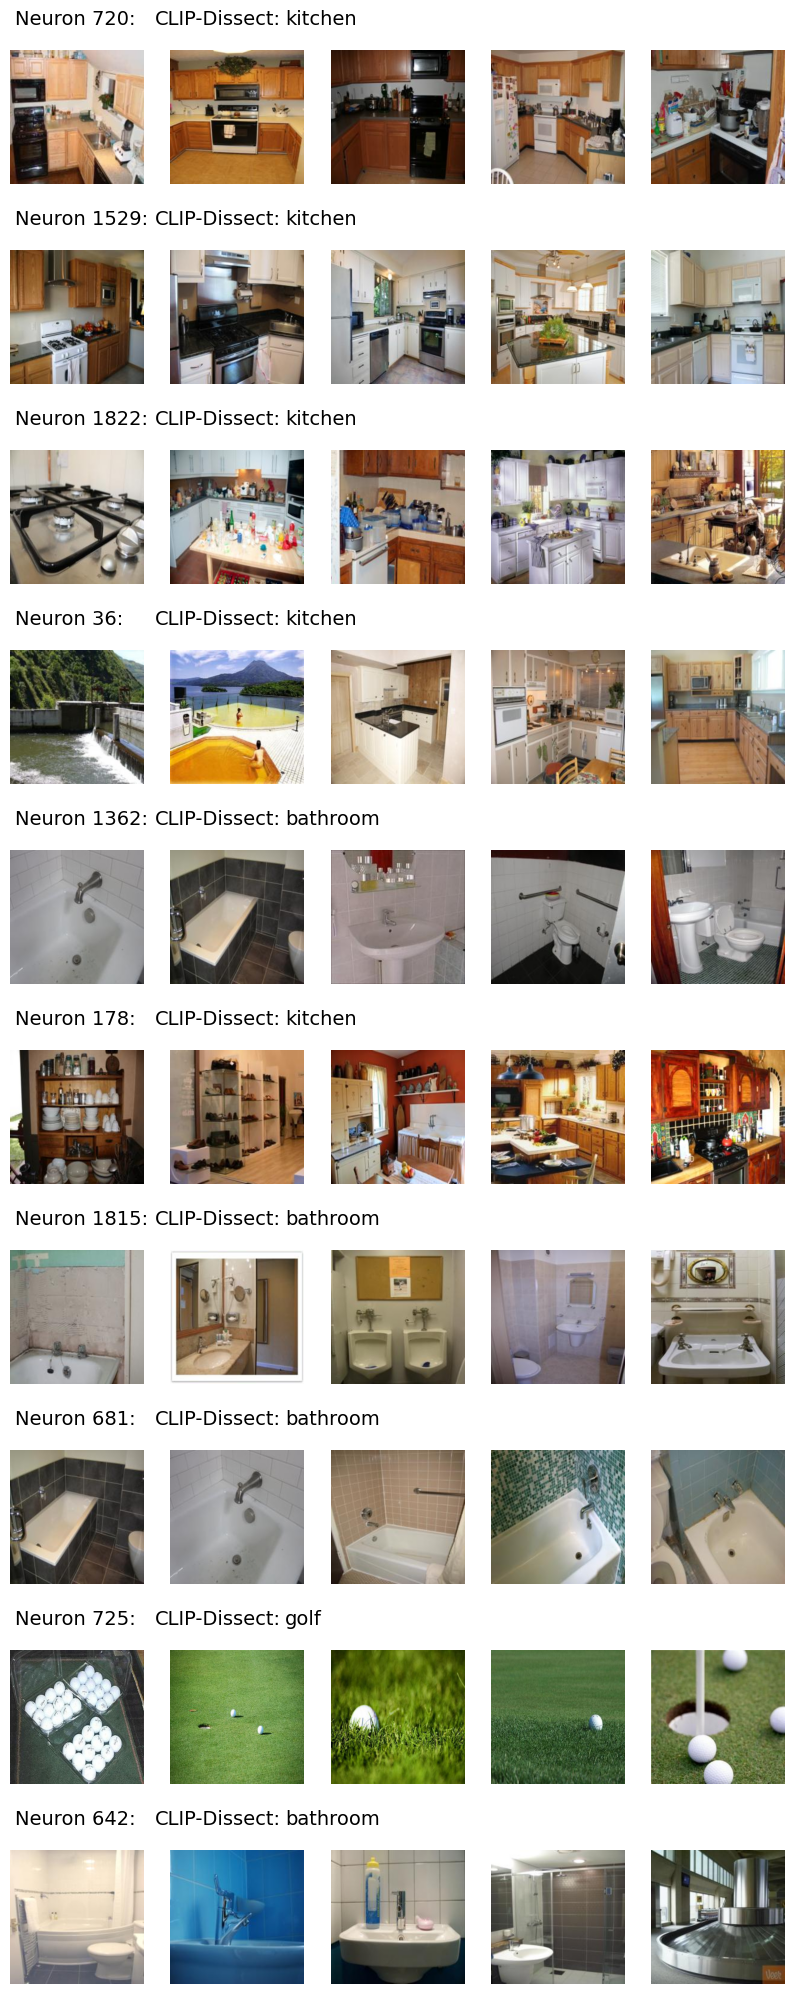

In [ ]:
neurons_to_check = torch.sort(torch.max(similarities, dim=1)[0], descending=True)[1][0:10]
font_size=14
font = {'size'   : font_size}

matplotlib.rc('font', **font)

fig = plt.figure(figsize=[10, len(neurons_to_check)*2])#constrained_layout=True)
subfigs = fig.subfigures(nrows=len(neurons_to_check), ncols=1)
for j, orig_id in enumerate(neurons_to_check):
    vals, ids = torch.topk(similarities[orig_id], k=5, largest=True)
        
    subfig = subfigs[j]
    subfig.text(0.13, 0.96, "Neuron {}:".format(int(orig_id)), size=font_size)
    subfig.text(0.27, 0.96, "CLIP-Dissect:", size=font_size)
    subfig.text(0.4, 0.96, words[int(ids[0])], size=font_size)
    axs = subfig.subplots(nrows=1, ncols=5)
    for i, top_id in enumerate(top_ids[:, orig_id]):
        im, label = pil_data[top_id]
        im = im.resize([375,375])
        axs[i].imshow(im)
        axs[i].axis('off')
plt.show()